<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5.2 Middleware 2 - MTConnect Adapter

## 2.1 Multiple MTConnect Adapters

In this part, we will run multiple MTConnect adapters so that each adapter is responsible for each sensor data collection. The schematic of this case is shown in Figure 10. Because we will collect data from three different sensors with different sampling periods each, three adapters,[lab5_adapter2-1.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-1.py?raw=true), [lab5_adapter2-2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-2.py?raw=true), and [lab5_adapter2-3.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-3.py?raw=true), are needed.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig10.png?raw=true" width="100%">


*Figure 10 MTConnect configuration 2: Multiple adapter case*

Please follow the steps below.
1.	Halt MTConnect agent (Shortcut: Ctrl + c on the ‘Terminal’)
2.	Modify ‘agent.cfg’ file to have 3 adapters as Figure 11.

  a.	Please note that each adapter **MUST** have **different port number**.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig11.png?raw=true" width="70%">
  
  *Figure 11 ‘agent.cfg’ for multiple MTConnect adapters*

3.	Don’t modify ‘Device.xml’.

  a.	We will use the same as before.
4.	Run the agent again.

Now, we are ready to run the adapter.

### Task 2.1

1.	Modify each sample adapter program to make all complete to have all values available. And then run all the adapters.  

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.






  ---

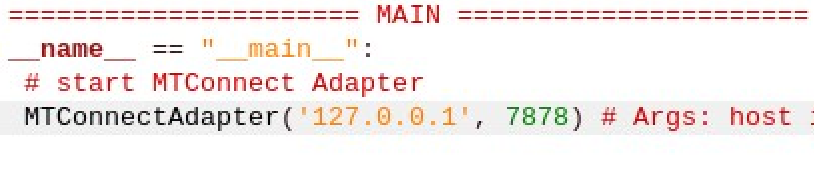


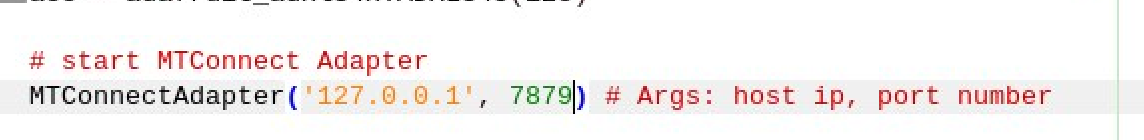


  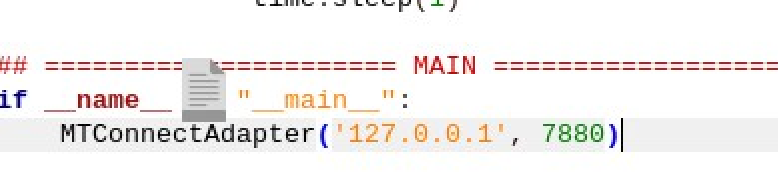
  ---

### Task 2.2
Place the entire Python code of each adapter to the report below in each appropiate section


In [ ]:
# MTConnet adapter sample for ME597 Lab5
# This code is for virtual sensor (random humidity value)
#          and temperature sensor (measure temperatrue)

import sys
import time
import datetime
from data_item import Event, Sample # load data_item package
from mtconnect_adapter import Adapter # load mtconnect_adapter package

import os
import glob
import random

class MTConnectAdapter(object): # MTConnect adapter object

    def __init__(self, host, port): # init of MTconnectAdapter class
        # MTConnect adapter connection info
        self.host = host # host arg of adapter
        self.port = port # port arg of adapter
        self.adapter = Adapter((host, port))

        # For samples
        self.t1 = Sample('t1') # self.t1 takes 't1' sample data item id.
        self.adapter.add_data_item(self.t1) # adding self.t1 in adapter
        ## Add more samples below, if needed.

        # For events
        ## Add more events below, if needed.

        # MTConnnect adapter availability
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # Start MTConnect
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()
        self.adapter_stream()

    def read_temp_raw(self):
        os.system('modprobe w1-gpio')
        os.system('modprobe w1-therm')
        base_dir = '/sys/bus/w1/devices/'
        device_folder = glob.glob(base_dir + '28*')[0]
        device_file = device_folder + '/w1_slave'
        f = open(device_file, 'r')
        lines = f.readlines()
        f.close()
        return lines

    def read_temp(self):
        lines = self.read_temp_raw()
        while lines[0].strip()[-3:] != 'YES':
            time.sleep(0.2)
            lines = self.read_temp_raw()
        equals_pos = lines[1].find('t=')
        if equals_pos != -1:
            temp_string = lines[1][equals_pos+2:]
            temp_c = float(temp_string) / 1000.0
            return temp_c

    def adapter_stream(self):
        while True:
            try:
                # Do something here
                # To halt this loop, short-cut is CTRL+C
                t1 = self.read_temp() # temperature
                # h1 = ? # Humidity (random input 50% - 70%)

                now = datetime.datetime.now() # get current data time

                self.adapter.begin_gather() # start to collection
                self.t1.set_value(str(t1)) # set SAMPLE value of h1 (temperature) data item
                self.adapter.complete_gather() # end of collection

                print("{} MTConnect data collection completed ... ".format(now)) # Printing out completed MTConnect collection
                print("DS18B20: Temperature={}°C\n".format(t1)) # Printing out DS18B20 measured values
                # print("Virtual: Humidity={}RH%\n".format(h1))

                time.sleep(2) # wait for 2 seconds = sampling period

            except KeyboardInterrupt: # To stop MTConnect adapter, Ctrl + c
                print("Stopping MTConnect...")
                self.adapter.stop() # Stop adapter thread
                sys.exit() # Terminate Python

## ====================== MAIN ======================
if __name__ == "__main__":
    # start MTConnect Adapter
    MTConnectAdapter('127.0.0.1', 7878) # Args: host ip, port number


In [ ]:
# MTConnet adapter sample for ME597 Lab5
# This code is for accelerometer sensor (measure acceleration)

import sys
import time
import datetime
from data_item import Event, Sample # load data_item package
from mtconnect_adapter import Adapter # load mtconnect_adapter package

import board
import busio
import adafruit_adxl34x

class MTConnectAdapter(object): # MTConnect adapter object

    def __init__(self, host, port): # init of MTconnectAdapter class
        # MTConnect adapter connection info
        self.host = host # host arg of adapter
        self.port = port # port arg of adapter
        self.adapter = Adapter((host, port))

        # For samples
        self.a1 = Sample('a1') # self.a1 takes 'a2' sample data item id.
        self.adapter.add_data_item(self.a1) # adding self.a2 in adapter
        self.a2 = Sample('a2') # self.a1 takes 'a1' sample data item id.
        self.adapter.add_data_item(self.a2) # adding self.a3 in adapter

        # For events
        ## Add more events below, if needed.

        # MTConnnect adapter availability
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # Start MTConnect
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()
        self.adapter_stream()


    def adapter_stream(self):
        while True:
            try:
                # Do something here
                # To halt this loop, short-cut is CTRL+C
                a = acc.acceleration # get acceleration
                # a1 = ?
                a2 = a[1] # get Y-axis acceleration
                a3 = a[2] # get Z-axis acceleration

                now = datetime.datetime.now() # get current data time

                self.adapter.begin_gather() # start to collection

                self.a2.set_value(str(a2)) # set SAMPLE value of a2 (Y-axis acceleration) data item
                self.a3.set_value(str(a3)) # set SAMPLE value of a3 (Z-axis acceleration) data item

                self.adapter.complete_gather() # end of collection

                print("{} MTConnect data collection completed ... ".format(now)) # Printing out completed MTConnect collection
                print("ADXL345: Yacc={}, Zacc={} mm/s^2\n".format(a2,a3)) # Printing out ADXL345 measured values

                time.sleep(1) # wait for 1 second = Sampling period

            except KeyboardInterrupt: # To stop MTConnect adapter, Ctrl + c
                print("Stopping MTConnect...")
                self.adapter.stop() # Stop adapter thread
                sys.exit() # Terminate Python


## ====================== MAIN ======================
if __name__ == "__main__":
    # i2c variable defines I2C interfaces and GPIO pins using busio and board modules
    i2c = busio.I2C(board.SCL, board.SDA)

    # acc object is instantiation using i2c of Adafruit ADXL34X library
    acc = adafruit_adxl34x.ADXL345(i2c)

    # start MTConnect Adapter
    MTConnectAdapter('127.0.0.1', 7879) # Args: host ip, port number


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# MTConnet adapter sample for ME597 Lab5
# This code is for power meter

import sys
import time
import datetime
from data_item import Event, Sample
from mtconnect_adapter import Adapter

from pymodbus.client.sync import ModbusTcpClient
from pymodbus.constants import Endian
from pymodbus.payload import BinaryPayloadDecoder


# function for power meter
def readReg(client, address, length=2, unit=1):
    rr = client.read_holding_registers(address=address, count=length, unit=unit)
    if rr is None or rr.isError():
        raise RuntimeError(f"Modbus read failed at address {address}: {rr}")

    decoder = BinaryPayloadDecoder.fromRegisters(
        rr.registers,
        byteorder=Endian.Big,
        wordorder=Endian.Big
    )
    return decoder.decode_32bit_float()


class MTConnectAdapter(object):

    def __init__(self, host, port):  # init of MTconnectAdapter class
        # MTConnect adapter connection info
        self.host = host
        self.port = port
        self.adapter = Adapter((host, port))

        # For samples
        self.p1 = Sample('p1')  # power (W)
        self.adapter.add_data_item(self.p1)

        # For events
        self.ps = Event('ps')  # power state
        self.adapter.add_data_item(self.ps)

        # MTConnnect adapter availability
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # Power meter Modbus TCP info
        self.pm_ip = "192.168.1.100"
        self.pm_port = 502
        self.pm_unit = 1

        self.power_reg_addr = 0000 # Address??
        self.power_reg_len = 2

        # Threshold for ON/OFF
        self.on_threshold_w = 5.0

        # Start MTConnect
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()

        self.adapter_stream()

    def adapter_stream(self):
        while True:
            try:
                c = ModbusTcpClient(self.pm_ip, port=self.pm_port, timeout=2)
                if not c.connect():
                    c.close()
                    raise RuntimeError(f"Failed to connect ModbusTcpClient to {self.pm_ip}:{self.pm_port}")

                # Read power (W)
#               p1 = ???

                # Determine power state
#               ps = ???

                now = datetime.datetime.now()

                self.adapter.begin_gather()
                self.p1.set_value(f"{p1:.3f}")
                self.ps.set_value(ps)
                self.adapter.complete_gather()

                print("{} MTConnect data collection completed ... ".format(now))
                print("Power meter: Machine is now {}, {:.3f} W\n".format(ps, p1))

                c.close()
                time.sleep(0.5)

            except KeyboardInterrupt:
                print("Stopping MTConnect...")
                self.adapter.stop()
                sys.exit()

            except Exception as e:
                print("Error:", e)
                try:
                    c.close()
                except Exception:
                    pass
                time.sleep(1)

## ====================== MAIN ======================
if __name__ == "__main__":
    MTConnectAdapter('127.0.0.1', 7880)


### Task 2.3

1.	On your laptop, run the MTConnect adapter for the power meter.

  * Please keep running MTConnect adapters for DS18B20 and ADXL345 on Raspberry Pi.
  
  * Hint:
        * You need to change ‘agent.cfg’ file.
        * You need to run the adapter Python code for power meter on laptop.
        * If it does not work, please check Windows firewall.

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.





  ---

  Place your screenshot for 2 here.

  ---

  3. In the text bock below, place changed parts in 'agent.cfg'.



---

```
Place changed part in 'agent.cfg' for Task 2.3.
```

---



  4. Discuss what changes were made.

  ---

  Write down your answer to 4 here.

  ---

Please keep your MTConnect stream working to perform the following Part (5.3).

<br></br>

Please continue to [Lab 5.3 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab3.ipynb).
